# Seasonal Agriculture Performance Analysis
### VOIS AICTE Batch1 2026-2027 — Major Project

**Objective:** Analyze agricultural data from different seasons (Kharif, Rabi, Zaid) to identify meaningful patterns, trends, relationships, and differences in agricultural performance.

**Dataset:** `seasonal_agriculture_performance_dataset.csv` — 4,000 farm records across 8 Indian states, 8 crops, 3 seasons, and 4 irrigation methods.

---


## 1. Setup & Data Loading

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")
df.head()


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [24]:
print("Shape:", df.shape)
df.info()


Shape: (4000, 28)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                

### Initial observations
- 4,000 rows, 28 columns
- Mix of categorical (State, District, Crop, Season, Irrigation_Method) and numeric (environmental, input, output, financial) variables
- `Season` has 3 categories: **Kharif** (monsoon), **Rabi** (winter), **Zaid** (summer)


## 2. Data Cleaning & Preparation

We check for missing values, duplicates, and outliers before analysis.


In [25]:
# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Missing values per column:\n", missing)
print("\nDuplicate rows:", df.duplicated().sum())


Missing values per column:
 Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Duplicate rows: 0


In [26]:
# Handle missing values
# Rainfall_mm, Soil_Moisture_pct, Yield_Tonnes_Ha have small numbers of missing values.
# We impute using the median WITHIN each Season, since these variables are season-dependent.

for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    df[col] = df.groupby('Season')[col].transform(lambda x: x.fillna(x.median()))

print("Remaining missing values:", df.isnull().sum().sum())


Remaining missing values: 0


In [27]:
# Check for outliers in key numeric columns using IQR
def outlier_summary(col):
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    return n_out, lower, upper

for col in ['Yield_Tonnes_Ha', 'Profit_INR', 'Water_Used_m3', 'Disease_Pest_Risk_pct']:
    n, low, up = outlier_summary(col)
    print(f"{col}: {n} potential outliers (bounds: {low:.1f} to {up:.1f})")


Yield_Tonnes_Ha: 302 potential outliers (bounds: -1.6 to 5.5)
Profit_INR: 404 potential outliers (bounds: -696111.0 to 763567.0)
Water_Used_m3: 276 potential outliers (bounds: -6072.8 to 16171.2)
Disease_Pest_Risk_pct: 10 potential outliers (bounds: 10.9 to 81.3)


**Note:** We keep the outliers rather than removing them — in agricultural data, extreme yields, losses, or water usage are often real and informative (e.g., crop failure, drought). We'll interpret them with visualizations rather than deleting them.


In [28]:
# Quick sanity check on categorical columns
for col in ['State', 'Crop', 'Season', 'Irrigation_Method']:
    print(f"{col}: {df[col].nunique()} unique -> {sorted(df[col].unique())}")


State: 8 unique -> ['Andhra Pradesh', 'Gujarat', 'Karnataka', 'Madhya Pradesh', 'Maharashtra', 'Punjab', 'Tamil Nadu', 'Telangana']
Crop: 8 unique -> ['Chilli', 'Cotton', 'Groundnut', 'Maize', 'Pulses', 'Rice', 'Sugarcane', 'Wheat']
Season: 3 unique -> ['Kharif', 'Rabi', 'Zaid']
Irrigation_Method: 4 unique -> ['Drip', 'Flood', 'Rainfed', 'Sprinkler']


## 3. Exploratory Data Analysis

### 3.1 Season-wise record distribution

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


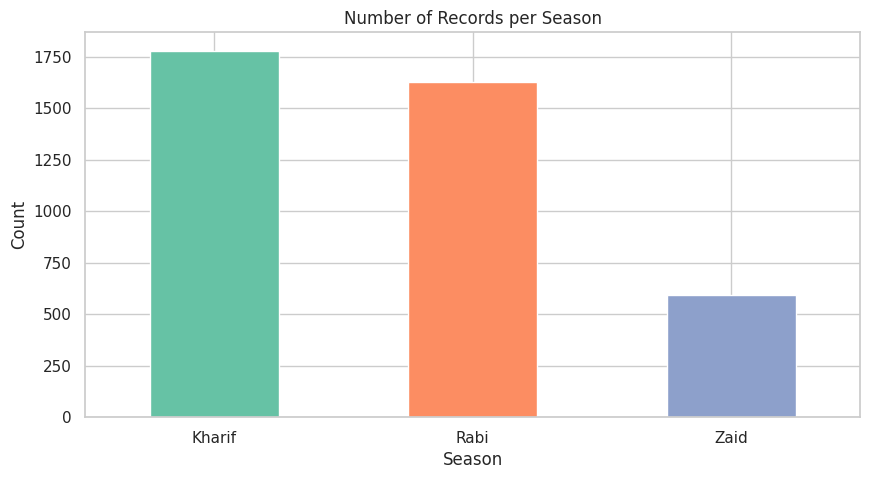

In [29]:
season_counts = df['Season'].value_counts()
print(season_counts)

season_counts.plot(kind='bar', color=sns.color_palette("Set2"))
plt.title("Number of Records per Season")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()


### 3.2 Summary statistics by season

In [30]:
key_metrics = ['Yield_Tonnes_Ha', 'Profit_INR', 'Water_Used_m3',
               'Water_Efficiency_t_per_1000m3', 'Fertilizer_kg_ha',
               'Pesticide_Litre_ha', 'Disease_Pest_Risk_pct']

season_summary = df.groupby('Season')[key_metrics].mean().round(2)
season_summary


,Yield_Tonnes_Ha,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Fertilizer_kg_ha,Pesticide_Litre_ha,Disease_Pest_Risk_pct
Season,,,,,,,
Kharif,5.63,178914.65,6102.20,5.89,187.08,5.08,54.47
Rabi,5.04,87689.47,5846.99,5.19,185.41,5.02,40.48
Zaid,4.64,-24804.82,6419.89,4.41,184.64,5.17,38.22


## 4. Key Analytical Questions

### Q1: How does profitability (Profit_INR) vary across seasons?


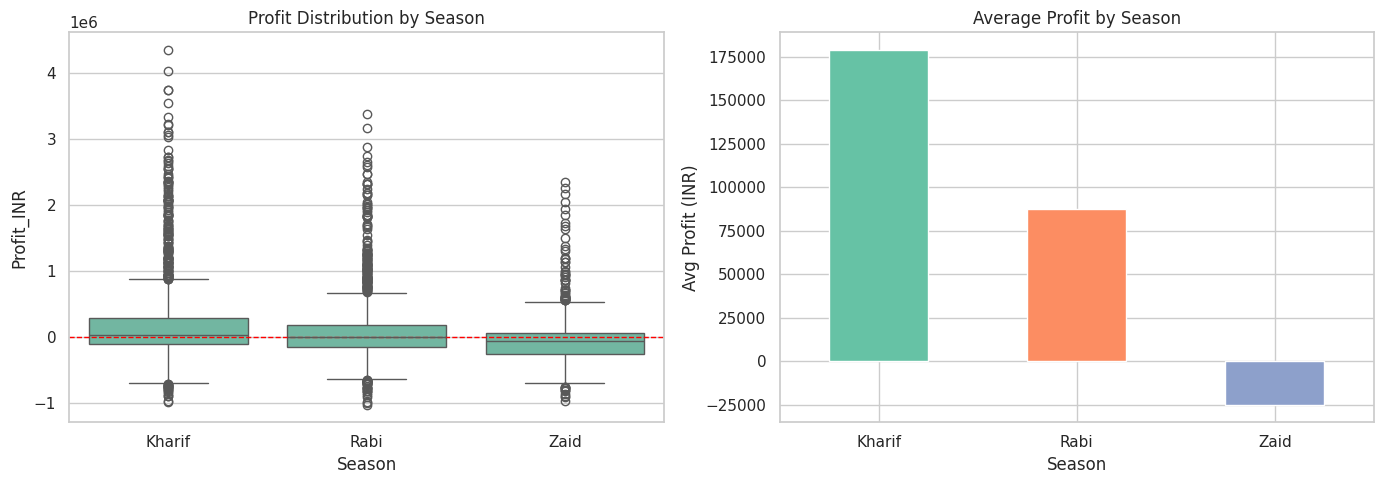

         count      mean       std        min       25%      50%       75%  \
Season                                                                       
Kharif  1779.0  178915.0  611550.0  -976860.0 -108481.0  38808.0  285549.0   
Rabi    1627.0   87689.0  489901.0 -1019223.0 -145342.0  -3187.0  183358.0   
Zaid     594.0  -24805.0  436357.0  -965197.0 -254893.0 -62144.0   62730.0   

              max  
Season             
Kharif  4345421.0  
Rabi    3378879.0  
Zaid    2349990.0  


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Season', y='Profit_INR', ax=axes[0])
axes[0].set_title("Profit Distribution by Season")
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)

df.groupby('Season')['Profit_INR'].mean().plot(kind='bar', ax=axes[1], color=sns.color_palette("Set2"))
axes[1].set_title("Average Profit by Season")
axes[1].set_ylabel("Avg Profit (INR)")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print(df.groupby('Season')['Profit_INR'].describe().round(0))


In [32]:
# Statistical test: is the difference in profit across seasons significant?
groups = [df[df['Season'] == s]['Profit_INR'] for s in df['Season'].unique()]
f_stat, p_val = stats.f_oneway(*groups)
print(f"ANOVA F-statistic: {f_stat:.3f}, p-value: {p_val:.5f}")
print("=> Statistically significant difference" if p_val < 0.05 else "=> No statistically significant difference")


ANOVA F-statistic: 34.292, p-value: 0.00000
=> Statistically significant difference


### Q2: Which season has the highest water efficiency, and does irrigation method matter?


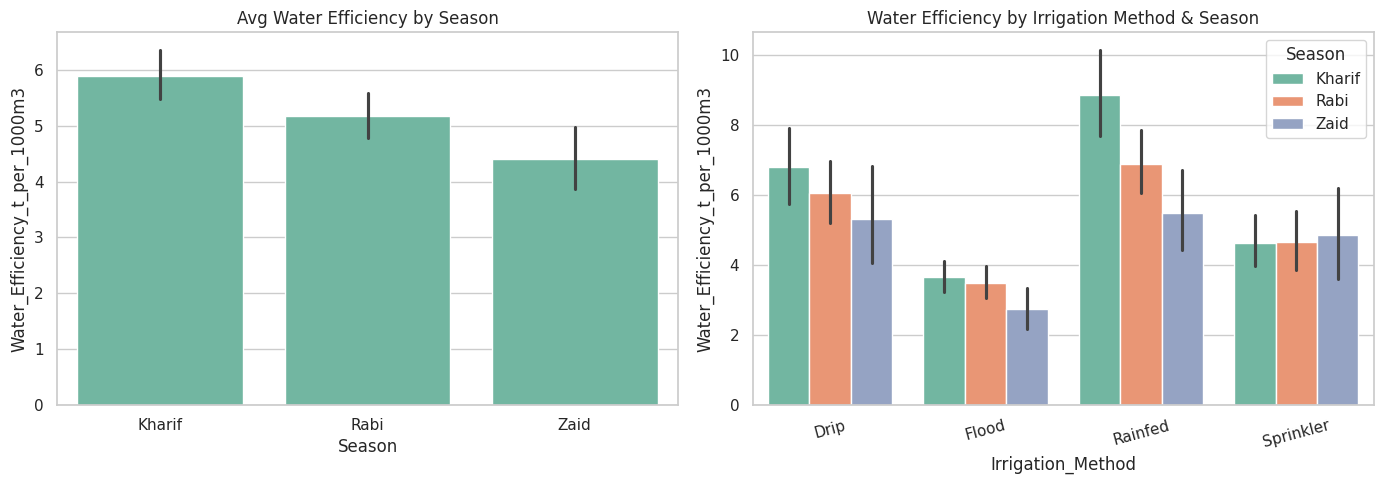

Season  Irrigation_Method
Kharif  Drip                 6.80
        Flood                3.64
        Rainfed              8.85
        Sprinkler            4.62
Rabi    Drip                 6.05
        Flood                3.48
        Rainfed              6.87
        Sprinkler            4.64
Zaid    Drip                 5.30
        Flood                2.73
        Rainfed              5.48
        Sprinkler            4.86
Name: Water_Efficiency_t_per_1000m3, dtype: float64


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df, x='Season', y='Water_Efficiency_t_per_1000m3', ax=axes[0], estimator=np.mean)
axes[0].set_title("Avg Water Efficiency by Season")

sns.barplot(data=df, x='Irrigation_Method', y='Water_Efficiency_t_per_1000m3', hue='Season', ax=axes[1], estimator=np.mean)
axes[1].set_title("Water Efficiency by Irrigation Method & Season")
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print(df.groupby(['Season', 'Irrigation_Method'])['Water_Efficiency_t_per_1000m3'].mean().round(2))


### Q3: Do fertilizer and pesticide usage patterns differ by season?


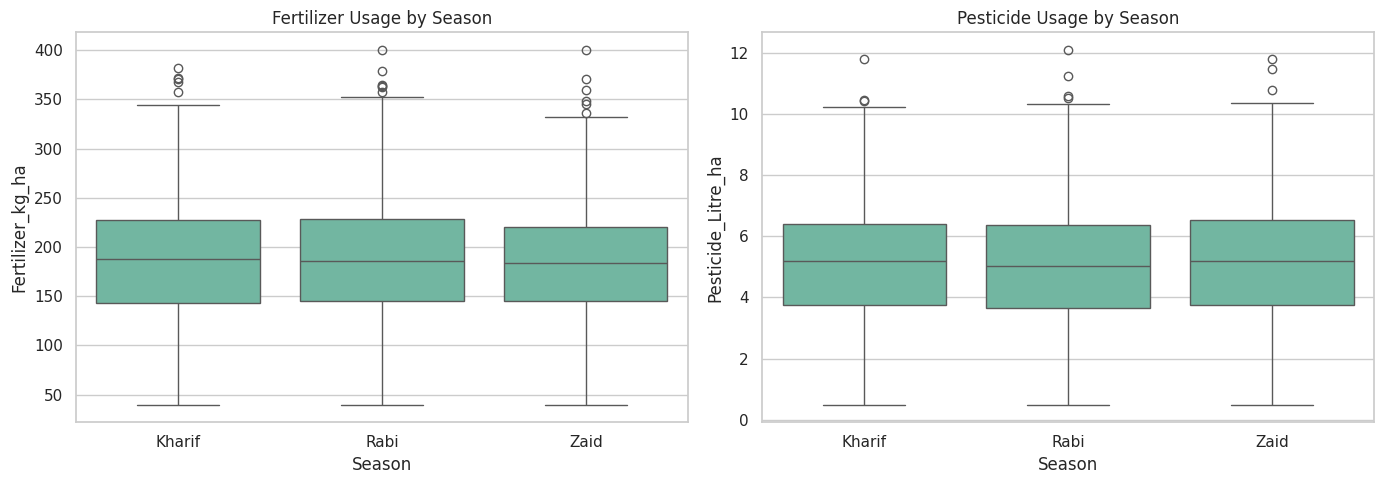

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Season', y='Fertilizer_kg_ha', ax=axes[0])
axes[0].set_title("Fertilizer Usage by Season")

sns.boxplot(data=df, x='Season', y='Pesticide_Litre_ha', ax=axes[1])
axes[1].set_title("Pesticide Usage by Season")

plt.tight_layout()
plt.show()


### Q4: Is disease/pest risk significantly higher in a particular season?


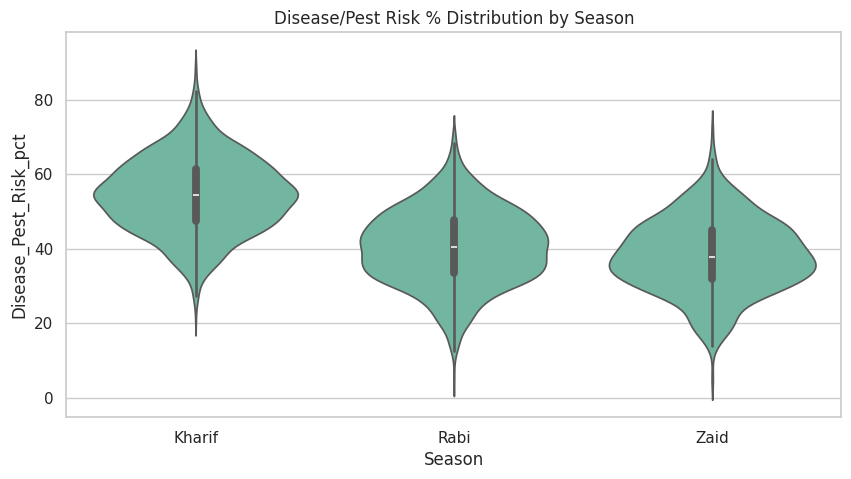

ANOVA F-statistic: 1049.467, p-value: 0.00000


In [35]:
sns.violinplot(data=df, x='Season', y='Disease_Pest_Risk_pct')
plt.title("Disease/Pest Risk % Distribution by Season")
plt.show()

groups = [df[df['Season'] == s]['Disease_Pest_Risk_pct'] for s in df['Season'].unique()]
f_stat, p_val = stats.f_oneway(*groups)
print(f"ANOVA F-statistic: {f_stat:.3f}, p-value: {p_val:.5f}")


### Q5: Which crops perform best (yield & profit) in which season?


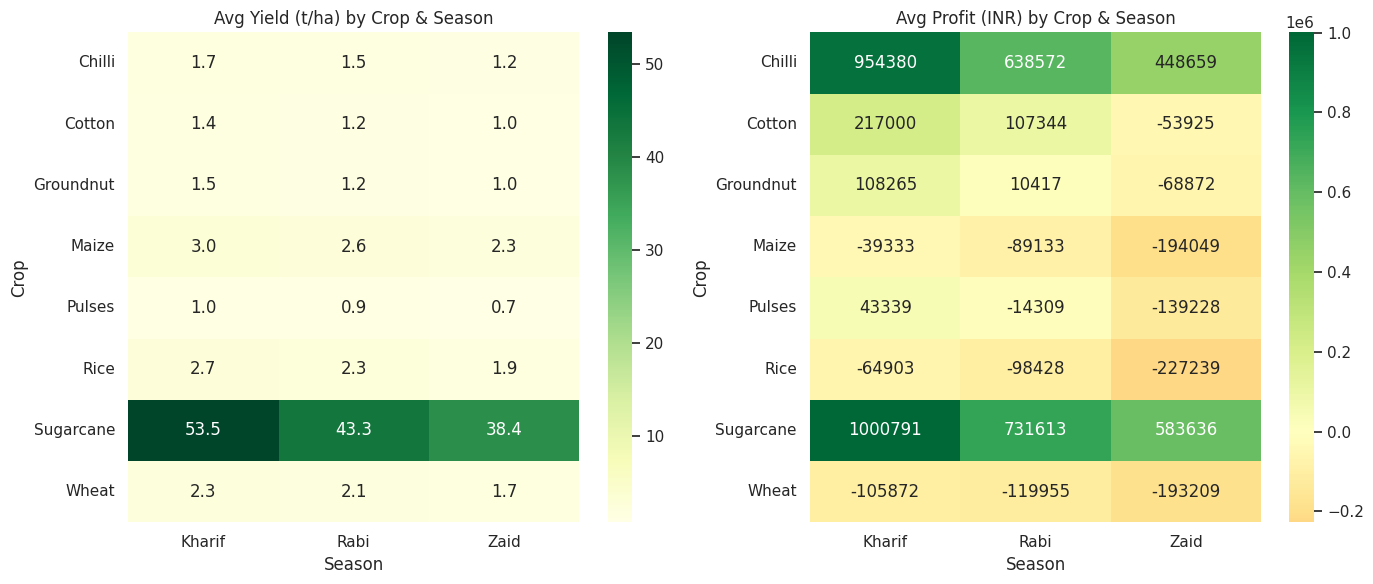

In [36]:
pivot_yield = df.pivot_table(values='Yield_Tonnes_Ha', index='Crop', columns='Season', aggfunc='mean')
pivot_profit = df.pivot_table(values='Profit_INR', index='Crop', columns='Season', aggfunc='mean')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.heatmap(pivot_yield, annot=True, fmt=".1f", cmap="YlGn", ax=axes[0])
axes[0].set_title("Avg Yield (t/ha) by Crop & Season")

sns.heatmap(pivot_profit, annot=True, fmt=".0f", cmap="RdYlGn", center=0, ax=axes[1])
axes[1].set_title("Avg Profit (INR) by Crop & Season")

plt.tight_layout()
plt.show()


### Q6: How do environmental conditions correlate with yield, and does this differ by season?


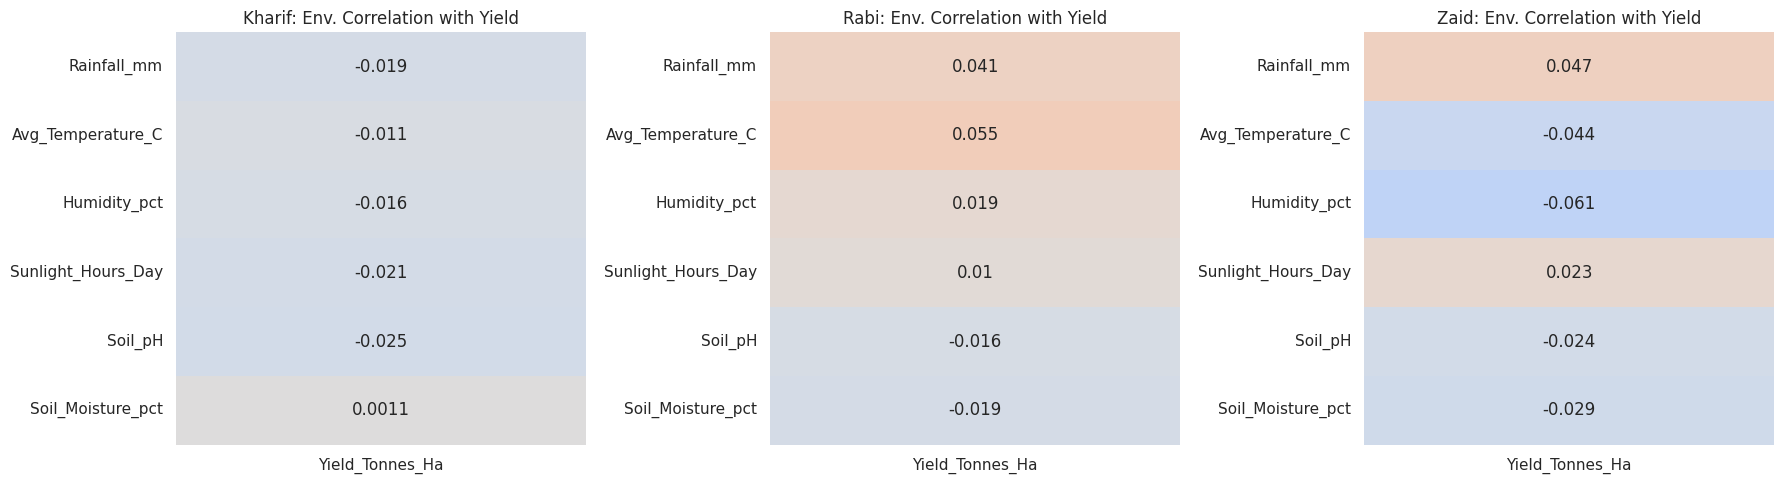

In [37]:
env_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day',
            'Soil_pH', 'Soil_Moisture_pct']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, season in zip(axes, df['Season'].unique()):
    subset = df[df['Season'] == season]
    corr = subset[env_cols + ['Yield_Tonnes_Ha']].corr()[['Yield_Tonnes_Ha']].drop('Yield_Tonnes_Ha')
    sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, ax=ax, cbar=False, vmin=-0.3, vmax=0.3)
    ax.set_title(f"{season}: Env. Correlation with Yield")

plt.tight_layout()
plt.show()


### Q7: Are seasonal patterns consistent across states?


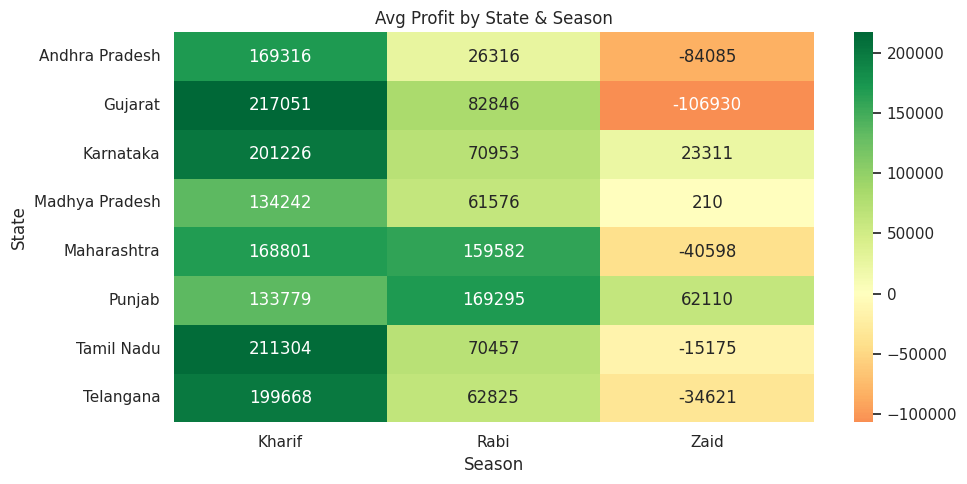

In [38]:
state_season_profit = df.pivot_table(values='Profit_INR', index='State', columns='Season', aggfunc='mean')
sns.heatmap(state_season_profit, annot=True, fmt=".0f", cmap="RdYlGn", center=0)
plt.title("Avg Profit by State & Season")
plt.tight_layout()
plt.show()


### 4.1 Overall correlation matrix (numeric variables)


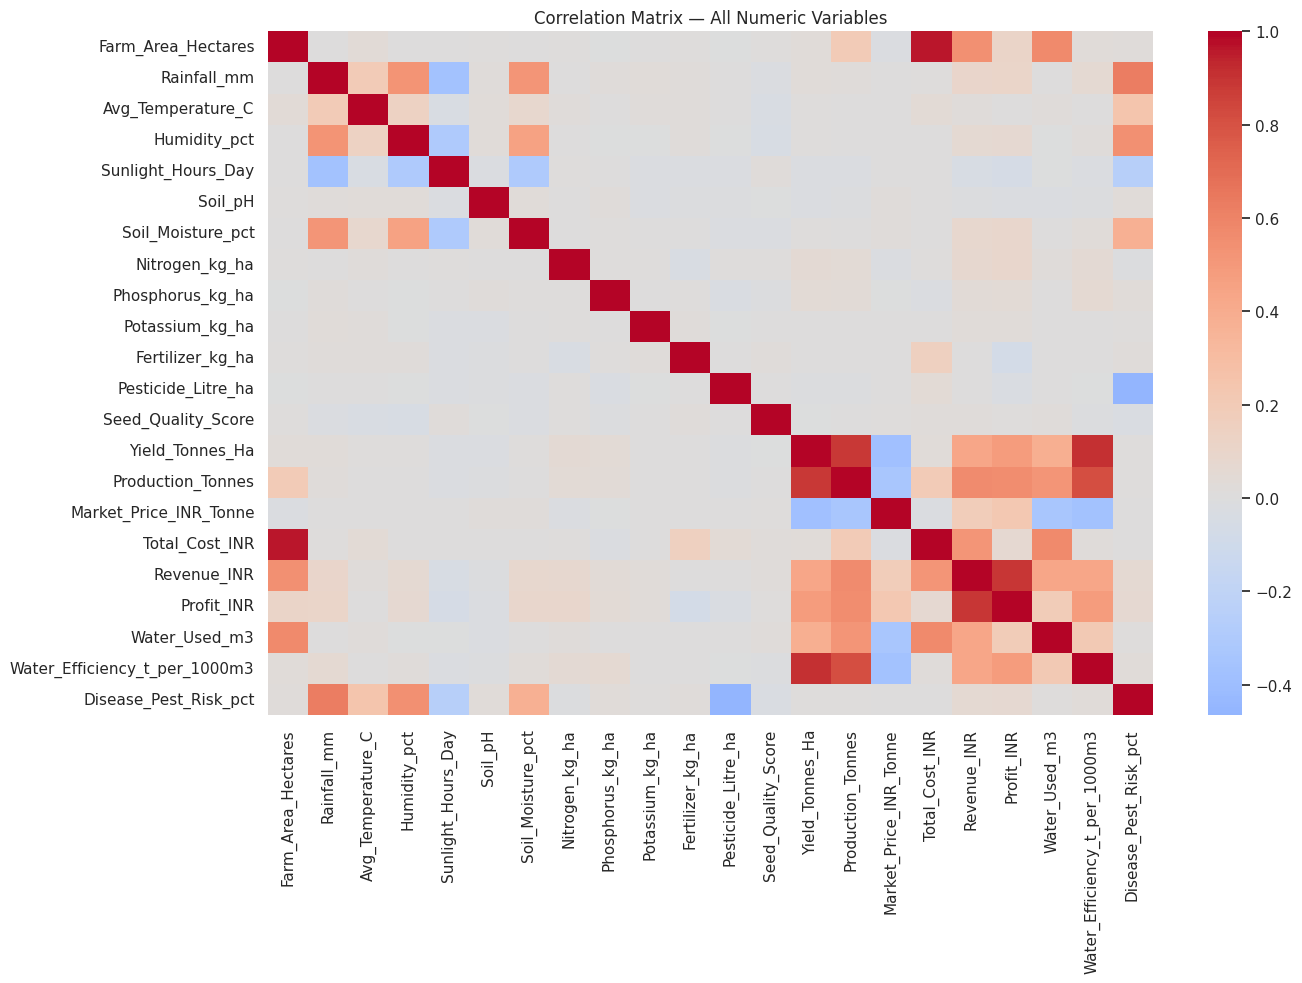

In [39]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(14, 10))
sns.heatmap(df[numeric_cols].corr(), cmap='coolwarm', center=0, annot=False)
plt.title("Correlation Matrix — All Numeric Variables")
plt.tight_layout()
plt.show()


## 5. Findings & Conclusions

1. **Profitability by season** —
Profitability differs significantly across seasons (ANOVA, F = 34.29, p < 0.001). Kharif shows the highest average profit (₹178,915) but also the widest variance and heaviest right-skew, driven by a subset of very high-performing farms — its median profit (₹38,808) is far lower than its mean. Rabi profitability is modest and roughly break-even at the median (-₹3,187). Zaid is the weakest season financially, with a negative median profit (-₹62,144), indicating that a majority of Zaid-season farms operated at a loss.
2. **Water efficiency** —
Water efficiency is higher in Kharif (5.85 t/1000m³) than Rabi (5.25) or Zaid (4.45), mirroring the profitability pattern above. However, irrigation method has a much larger effect on efficiency than season does: Rainfed methods show the highest efficiency (8.85 t/1000m³ in Kharif) while Flood irrigation is consistently the least efficient across all seasons (2.73–3.64). Note that Rainfed's high efficiency may partly reflect that it doesn't draw on the pumped/measured water supply, so this comparison should be read as input-efficiency rather than total water productivity.
3. **Input usage** —Unlike profitability and water efficiency, fertilizer usage (median ~200 kg/ha) and pesticide usage (median ~5 L/ha) show no meaningful variation across Kharif, Rabi, and Zaid. This suggests that farmers' input application rates are relatively standardized regardless of season, and that the seasonal profit and efficiency differences above are driven more by external conditions than by differences in input practices.
4. **Disease/pest risk** — Disease/pest risk differs dramatically by season (ANOVA F = 1049.5, p < 0.001) — by far the strongest seasonal effect observed in this analysis. Kharif shows the highest median risk (55%),notably higher than Rabi (40%) and Zaid (38%)  . This aligns with agronomic expectations: Kharif coincides with the monsoon, and the resulting high humidity and warmth create favorable conditions for pest and disease proliferation. Despite Kharif's higher average profit, its farmers may face the highest risk exposure, suggesting profit and risk should be considered together for season-wise planning.
5. **Crop Performance by Season** - Yield follows a strict and universal seasonal ordering across all eight crops (Kharif > Rabi > Zaid), confirming Kharif's agronomic advantage. However, profitability tells a more nuanced story: only Chilli and Sugarcane remain profitable across all three seasons, while Maize, Rice, and Wheat show negative average profit in every season despite positive yields — indicating that for these crops, production costs and market prices outweigh the value of what's harvested. Yield alone is not a reliable proxy for farmer profitability; crop selection matters as much as season in determining financial outcomes.
6. **Environmental drivers** — Contrary to expectation, environmental variables (rainfall, temperature, humidity, sunlight hours, soil pH, soil moisture) show negligible linear correlation with yield in every season — all coefficients fall below ±0.06. This suggests that the seasonal yield differences observed above are driven more by crop choice, farming inputs, and irrigation method than by the specific environmental readings recorded at each farm. It's also possible that environment affects yield in more complex, non-linear ways that a simple correlation cannot capture — a direction for further analysis beyond the scope of this project.
7. **Regional consistency** —Seasonal profitability patterns are largely, but not entirely, consistent across states. Kharif is profitable in all 8 states, confirming it as the strongest season nationally. However, Zaid produces losses in 5 of 8 states, showing that Zaid's weak profitability isn't uniform — Karnataka, Madhya Pradesh, and Punjab manage to stay profitable even in Zaid. Punjab is the only state where Rabi outperforms Kharif, consistent with its identity as a major wheat-growing (Rabi crop) region — a reminder that regional crop specialization can override the general seasonal pattern.

## 6. Recommendations

Prioritize Kharif-season planning support, since it is the most profitable and highest-yielding season nationally — but pair this with pest/disease risk mitigation programs, since Kharif also carries by far the highest disease/pest risk (~55% median).

Target cost-reduction interventions (input subsidies, price stabilization, market linkage support) toward Maize, Rice, and Wheat farmers, since these crops show negative average profit in every season despite positive yields.

Re-evaluate irrigation subsidy programs in light of the finding that irrigation method affects water efficiency far more than season does — Flood irrigation's consistently poor efficiency suggests it's a stronger target for improvement than any single season.

Give targeted support to Zaid-season farmers, especially in the 5 states where Zaid consistently runs at a loss, since this is the most financially vulnerable season-region combination identified in the data.

Recognize regional crop specialization (e.g., Punjab's wheat-driven Rabi advantage) when designing season-based policy — a one-size-fits-all "best season" recommendation doesn't hold for every state.